# Notebook 03 — Six-model comparison and ecCount inference

**Purpose.** This notebook compares all six benchmark models on the same anchor image, runs ecCount live to demonstrate the inference pipeline, and reproduces the headline benchmark numbers from the frozen CSVs.

**Audience.** A collaborator who wants to see (a) what each model's predictions actually look like, (b) how ecCount works end-to-end from RGB image to peaks, and (c) the quantitative comparison across cell lines and count regimes.

**Models compared (six total):**
1. `Classic (after opt)` — classical pipeline with BO-frozen parameters
2. `Label Engine` — external pretrained baseline
3. `ecSeg` — external pretrained baseline (Rajkumar et al.)
4. `MIA` — our previous deep-learning model
5. `ecCount (threshold mask)` — ecCount probability map thresholded at 0.35
6. `ecCount (peaks)` — ecCount peak detection followed by NMS

**What this notebook produces** (all files written to `release/figures/notebook03/`):

| File | Description |
|------|-------------|
| `fig4_qualitative_six_models.svg` | Anchor-image predictions for all six models |
| `fig5_probability_map.svg` | ecCount raw probability map next to its RGB input |
| `fig5_postproc_steps.svg` | Five-step ecCount postprocessing strip |
| `fig5_threshold_vs_peaks.svg` | Threshold mask vs peaks mask, full image |
| `fig5_threshold_vs_peaks_zoomed.svg` | Threshold mask vs peaks mask, anchor crop |
| `fig5_training_curves.svg` | ecCount training and validation loss curves |
| `fig6_f1_overall.svg` | Object-level F1 per model (all splits) |
| `fig6_f1_by_cell_line.svg` | F1 grouped by cell line |
| `fig6_f1_by_density.svg` | F1 by ecDNA count bin |
| `fig6_count_agreement.svg` | Predicted vs GS count scatter, log-log |
| `fig6_test_only.svg` | Pooled object-level F1 on the held-out test split |
| `fig6_test_count_mae.svg` | Pooled count MAE on the held-out test split |

Benchmark numbers come from `release/frozen_results/or_matching/`. The live ecCount inference in §3 is illustrative only — the headline benchmark numbers are *not* recomputed from it.


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import cv2
from IPython.display import display

# ── Repo root ───────────────────────────────────────────────────────────────
REPO_ROOT = Path(os.getcwd()).parent
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path(os.getcwd())
print(f'Repo root: {REPO_ROOT}')

SRC_DIR = REPO_ROOT / 'src'
sys.path.insert(0, str(SRC_DIR if SRC_DIR.exists() else REPO_ROOT))
print(f'Python import path: {SRC_DIR if SRC_DIR.exists() else REPO_ROOT}')

# ── Paths ───────────────────────────────────────────────────────────────────
import os
DATA_ROOT = Path(os.environ.get('ECDNA_DATA_ROOT', '/proj/brunk_ecdna_cv_project/Poorya/ecDNA_Data/bia_view')) / 'images'
RGB_DIR   = DATA_ROOT / 'rgb'
GT_DIR    = DATA_ROOT / 'gt_image'
ROI_DIR   = DATA_ROOT / 'roi_mask'

MANIFESTS  = REPO_ROOT / 'release' / 'manifests'
FROZEN_OR  = REPO_ROOT / 'release' / 'frozen_results' / 'or_matching'

# Harmonized prediction mask directories
MASKS_BASE = REPO_ROOT / 'release' / 'harmonized_masks'
MASK_DIRS = {
    'Classic (after opt)':       MASKS_BASE / 'classical',
    'Label Engine':              MASKS_BASE / 'label_engine',
    'ecSeg':                     MASKS_BASE / 'ecseg',
    'MIA':                       MASKS_BASE / 'mia',
    'ecCount (threshold mask)':  (DATA_ROOT.parent / 'predictions' / 'eccount_threshold'),
    'ecCount (peaks)':           (DATA_ROOT.parent / 'predictions' / 'eccount_peaks'),
}

# ecCount training outputs
ECCOUNT_CKPT = REPO_ROOT / 'release' / 'model_checkpoints' / 'eccount_best.pt'
TRAIN_HIST   = REPO_ROOT / 'outputs' / 'eccount_training' / 'train_history.csv'

FULL_META_CSV = DATA_ROOT / 'metadata_internal.csv'

# Output directory
OUT_DIR = REPO_ROOT / 'release' / 'figures' / 'notebook03'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'SVG output: {OUT_DIR}')

# ── Anchor image ────────────────────────────────────────────────────────────
ANCHOR_UID        = 'ncih2170_facs_fish_0723_low_her2_52'
ANCHOR_INSET_BBOX = [1247, 1225, 1458, 1353]

# ── Palettes ────────────────────────────────────────────────────────────────
MODEL_COLORS = {
    'Classic (after opt)':       '#54A24B',
    'Label Engine':              '#E45756',
    'ecSeg':                     '#B279A2',
    'MIA':                       '#4C78A8',
    'ecCount (threshold mask)':  '#9C755F',
    'ecCount (peaks)':           '#F58518',
}
MODEL_ORDER = list(MODEL_COLORS.keys())

CELL_LINE_COLORS = {
    'NCI-H2170': '#E69F00',
    'SNU16':     '#009E73',
    'COLO320DM': '#CC79A7',
    'NCI-H716':  '#0072B2',
}
CL_ORDER = ['NCI-H2170', 'SNU16', 'COLO320DM', 'NCI-H716']

DENSITY_ORDER  = ['0-9', '10-49', '50-149', '150-299', '300+']
DENSITY_COLORS = {
    '0-9': '#FFFFB2', '10-49': '#FECC5C', '50-149': '#FD8D3C',
    '150-299': '#F03B20', '300+': '#BD0026',
}

# ── Publication style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':         7,
    'axes.titlesize':    8,
    'axes.labelsize':    7,
    'xtick.labelsize':   6.2,
    'ytick.labelsize':   6.2,
    'legend.fontsize':   6.2,
    'figure.titlesize':  8,
    'axes.linewidth':    0.8,
    'lines.linewidth':   1.2,
    'savefig.dpi':       300,
    'svg.fonttype':      'none',
    'pdf.fonttype':      42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

def save_fig(fig, name):
    svg = OUT_DIR / f'{name}.svg'
    png = OUT_DIR / f'{name}.png'
    fig.savefig(svg, format='svg', bbox_inches='tight')
    fig.savefig(png, format='png', dpi=150, bbox_inches='tight')
    print(f'  Saved: {svg.name}')

def canonical_cell_line(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper().replace('-','').replace('_','').replace(' ','')
    return {'NCIH2170':'NCI-H2170','SUM159PT':'SUM159PT','SNU16':'SNU16',
            'COLO320DM':'COLO320DM','NCIH716':'NCI-H716'}.get(s, str(x).strip())

print('Setup complete.')

Repo root: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench
Python import path: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/src
SVG output: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03
Setup complete.


## §1 — Loading the anchor image and all six predictions

We load the anchor RGB, GS, ROI, and the harmonized prediction masks for all six
models. Each prediction mask is a binary PNG `{0, 255}` at original image
resolution; this is the canonical evaluation format used throughout the benchmark.

In [2]:
# ── Load anchor RGB / GS / ROI ──────────────────────────────────────────────
full_meta = pd.read_csv(FULL_META_CSV)
full_meta['cell_line_display'] = full_meta['cell_line'].apply(canonical_cell_line)
anchor_row = full_meta[full_meta['unique_id'] == ANCHOR_UID].iloc[0]

def find_image(base_dir, uid, row, col_name):
    if col_name in row.index and pd.notna(row[col_name]):
        p = Path(base_dir) / row[col_name]
        if p.exists(): return p
    for ext in ['.png', '.tif', '.tiff']:
        candidates = list(Path(base_dir).rglob(f'{uid}{ext}'))
        if candidates: return candidates[0]
    return None

anchor_rgb_path = find_image(RGB_DIR, ANCHOR_UID, anchor_row, 'rgb_filename')
anchor_gt_path  = find_image(GT_DIR,  ANCHOR_UID, anchor_row, 'gt_image_filename')
anchor_roi_path = find_image(ROI_DIR, ANCHOR_UID, anchor_row, 'roi_mask_filename')

anchor_rgb = cv2.cvtColor(cv2.imread(str(anchor_rgb_path)), cv2.COLOR_BGR2RGB)
anchor_gt  = cv2.imread(str(anchor_gt_path),  cv2.IMREAD_GRAYSCALE)
anchor_roi = cv2.imread(str(anchor_roi_path), cv2.IMREAD_GRAYSCALE)
anchor_gt_bin  = (anchor_gt  > 0).astype(np.uint8)
anchor_roi_bin = (anchor_roi > 0).astype(np.uint8)
H, W = anchor_rgb.shape[:2]
print(f'Anchor: {ANCHOR_UID}  shape: {H} × {W}')

Anchor: ncih2170_facs_fish_0723_low_her2_52  shape: 2048 × 2448


In [3]:
# ── Load harmonized prediction masks for the anchor from each of 6 models ───
def load_mask_for_uid(mask_dir, uid):
    """Load a {0,255} binary mask PNG for a given UID. Returns None if missing."""
    candidates = list(mask_dir.glob(f'{uid}.png')) + list(mask_dir.glob(f'{uid}.PNG'))
    if not candidates:
        # Try recursive glob
        candidates = list(mask_dir.rglob(f'{uid}.png'))
    if not candidates:
        return None
    m = cv2.imread(str(candidates[0]), cv2.IMREAD_GRAYSCALE)
    return (m > 0).astype(np.uint8) if m is not None else None

preds = {}
for model_name, mask_dir in MASK_DIRS.items():
    if not mask_dir.exists():
        print(f'  ✗ {model_name}: directory not found ({mask_dir})')
        preds[model_name] = None
        continue
    m = load_mask_for_uid(mask_dir, ANCHOR_UID)
    if m is None:
        print(f'  ✗ {model_name}: anchor mask not found in {mask_dir}')
    else:
        print(f'  ✓ {model_name}: loaded ({m.sum():,} fg pixels)')
    preds[model_name] = m

  ✓ Classic (after opt): loaded (11,272 fg pixels)
  ✓ Label Engine: loaded (3,867 fg pixels)
  ✓ ecSeg: loaded (3,201 fg pixels)
  ✓ MIA: loaded (5,620 fg pixels)
  ✓ ecCount (threshold mask): loaded (4,960 fg pixels)
  ✓ ecCount (peaks): loaded (1,508 fg pixels)


### Per-model QC of the loaded anchor masks

Before plotting we check the six prediction masks loaded above for shape consistency, foreground pixel counts, and the number of 8-connected components with min area 3 px. These QC numbers also feed the title text of the qualitative figure two cells down (each panel reports the per-model object count for the anchor image).


In [4]:
# ── Lightweight QC summary for anchor masks ─────────────────────────────────
# Avoid full object matching here: dense pairwise matching can be expensive in
# limited Jupyter sessions. This cell only checks shape, foreground pixels, and
# connected-component counts for the six anchor predictions.

from scipy import ndimage as ndi

def count_components(mask, min_area=3):
    lab, n = ndi.label((mask > 0).astype(np.uint8), structure=np.ones((3, 3)))
    if n == 0:
        return 0
    sizes = np.bincount(lab.ravel())
    return int((sizes[1:] >= min_area).sum())

qc_rows = []

gt_cc = count_components(anchor_gt_bin, min_area=3)

for model_name in MODEL_ORDER:
    mask = preds.get(model_name)

    if mask is None:
        qc_rows.append({
            'model': model_name,
            'shape_ok': False,
            'foreground_pixels': np.nan,
            'pred_components_min3': np.nan,
        })
        continue

    shape_ok = (mask.shape == anchor_gt_bin.shape)

    qc_rows.append({
        'model': model_name,
        'shape_ok': shape_ok,
        'foreground_pixels': int(mask.sum()),
        'pred_components_min3': count_components(mask, min_area=3),
    })

anchor_mask_qc = pd.DataFrame(qc_rows)

print(f'Anchor GS components, min area 3 px: {gt_cc:,}')
display(anchor_mask_qc)

source_csv = OUT_DIR / 'source_anchor_mask_qc.csv'
anchor_mask_qc.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

Anchor GT components, min area 3 px: 116


,model,shape_ok,foreground_pixels,pred_components_min3
0,Classic (after opt),True,11272,95
1,Label Engine,True,3867,102
2,ecSeg,True,3201,88
3,MIA,True,5620,112
4,ecCount (threshold mask),True,4960,112
5,ecCount (peaks),True,1508,116


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_anchor_mask_qc.csv


### Raw prediction masks on the anchor inset

Before applying object matching, we first inspect the six canonical prediction
masks directly on the same anchor crop. This lightweight visual QC confirms
that all model outputs are aligned to the original image coordinates and makes
the qualitative differences between methods visible without imposing the
TP/FP/FN matching rule.

## §2 — Qualitative six-model comparison on the anchor image

This section is a visual comparison, not the primary benchmark. The goal is to show how the six model outputs differ on the same microscopy field before turning to frozen aggregate metrics in §§5–10.

For the anchor image, we display each canonical prediction mask on the same expanded crop. Gold-standard ecDNA contours are shown in white and each model's prediction is overlaid in its model-specific colour. The panel is paired with a lightweight object-count QC table so that obvious qualitative differences can be interpreted in context.

The formal object-level comparison is not recomputed live here. Instead, the benchmark sections below read the frozen `release/frozen_results/or_matching/` CSVs, which contain the full six-model evaluation across all benchmark images.


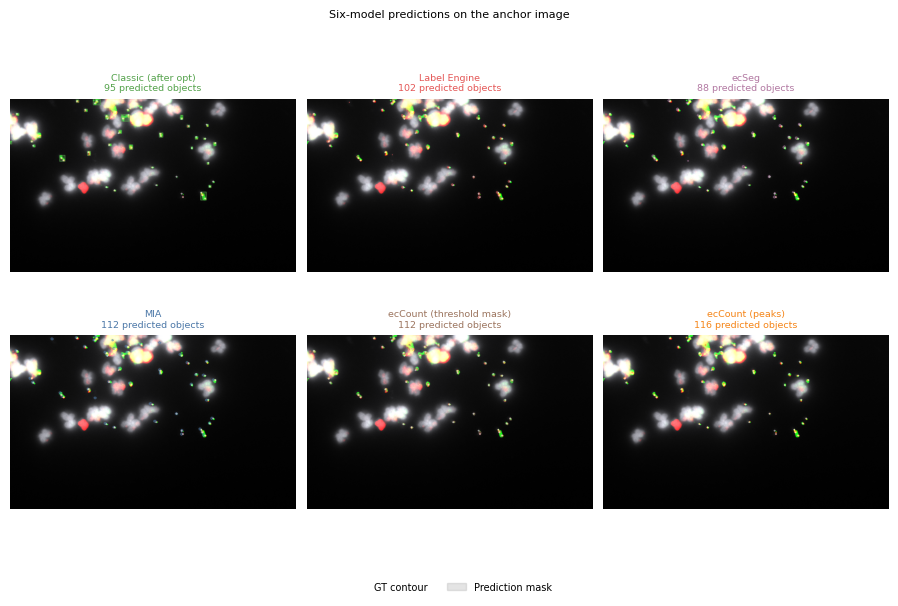

  Saved: fig4_qualitative_six_models.svg
Crop shown: x=930:1774, y=1033:1545


In [5]:
# ── Fig 4: Six-model qualitative comparison on anchor crop ──────────────────
# Lightweight qualitative panel:
#   RGB crop + GS contour (white) + prediction contour / mask tint.
# This avoids running full-image object matching inside the notebook.

def crop_with_padding(bbox, image_shape, scale=2.0):
    """Return an expanded crop around bbox, clipped to image bounds."""
    x0, y0, x1, y1 = bbox
    h, w = image_shape[:2]

    cx = (x0 + x1) // 2
    cy = (y0 + y1) // 2
    half_w = int((x1 - x0) * scale)
    half_h = int((y1 - y0) * scale)

    ex0 = max(0, cx - half_w)
    ex1 = min(w, cx + half_w)
    ey0 = max(0, cy - half_h)
    ey1 = min(h, cy + half_h)

    return ex0, ey0, ex1, ey1


def normalise_rgb_for_display(rgb):
    """Robustly enhance RGB contrast for visualization only."""
    arr = rgb.astype(np.float32)
    out = np.zeros_like(arr, dtype=np.float32)

    for c in range(3):
        lo, hi = np.percentile(arr[..., c], [1, 99.5])
        if hi <= lo:
            out[..., c] = arr[..., c]
        else:
            out[..., c] = np.clip((arr[..., c] - lo) / (hi - lo), 0, 1)

    return (255 * out).astype(np.uint8)


def overlay_mask_and_contours(rgb_crop, pred_crop, gt_crop, color_hex, alpha=0.35):
    """
    Overlay one prediction mask on the RGB crop.

    Prediction:
      - translucent model-colour fill
      - model-colour contour

    Gold standard:
      - white contour
    """
    base = normalise_rgb_for_display(rgb_crop)
    out = base.copy().astype(np.float32)

    color_rgb = np.array([
        int(color_hex[1:3], 16),
        int(color_hex[3:5], 16),
        int(color_hex[5:7], 16),
    ], dtype=np.float32)

    pred_bin = (pred_crop > 0).astype(np.uint8)
    gt_bin = (gt_crop > 0).astype(np.uint8)

    # Prediction translucent fill
    pred_pixels = pred_bin > 0
    out[pred_pixels] = (1 - alpha) * out[pred_pixels] + alpha * color_rgb

    out = np.clip(out, 0, 255).astype(np.uint8)

    # Prediction contour
    pred_contours, _ = cv2.findContours(pred_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(
        out,
        pred_contours,
        -1,
        tuple(int(v) for v in color_rgb.tolist()),
        thickness=1,
        lineType=cv2.LINE_AA,
    )

    # GS contour in white
    gt_contours, _ = cv2.findContours(gt_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(
        out,
        gt_contours,
        -1,
        (255, 255, 255),
        thickness=1,
        lineType=cv2.LINE_AA,
    )

    return out


# Expanded anchor crop for visibility
ex0, ey0, ex1, ey1 = crop_with_padding(
    ANCHOR_INSET_BBOX,
    anchor_rgb.shape,
    scale=2.0,
)

rgb_crop = anchor_rgb[ey0:ey1, ex0:ex1]
gt_crop = anchor_gt_bin[ey0:ey1, ex0:ex1]
roi_crop = anchor_roi_bin[ey0:ey1, ex0:ex1]

fig, axes = plt.subplots(2, 3, figsize=(9.0, 5.8))
axes = axes.flatten()

for ax, model_name in zip(axes, MODEL_ORDER):
    mask = preds.get(model_name)

    if mask is None:
        ax.text(
            0.5, 0.5,
            'Prediction\nnot available',
            ha='center',
            va='center',
            transform=ax.transAxes,
            fontsize=8,
            color='red',
        )
        ax.set_title(model_name, fontsize=7, color=MODEL_COLORS[model_name])
        ax.axis('off')
        continue

    if mask.shape != anchor_gt_bin.shape:
        raise ValueError(
            f'{model_name} mask shape mismatch: {mask.shape} vs {anchor_gt_bin.shape}'
        )

    pred_crop = mask[ey0:ey1, ex0:ex1]

    panel = overlay_mask_and_contours(
        rgb_crop=rgb_crop,
        pred_crop=pred_crop,
        gt_crop=gt_crop,
        color_hex=MODEL_COLORS[model_name],
        alpha=0.35,
    )

    pred_cc = int(anchor_mask_qc.loc[
        anchor_mask_qc['model'] == model_name,
        'pred_components_min3'
    ].iloc[0])

    ax.imshow(panel)
    ax.set_title(
        f'{model_name}\n{pred_cc:,} predicted objects',
        fontsize=6.8,
        color=MODEL_COLORS[model_name],
    )
    ax.axis('off')

legend_handles = [
    Line2D([0], [0], color='white', lw=1.5, label='GS contour'),
    mpatches.Patch(facecolor='0.7', edgecolor='0.7', alpha=0.35, label='Prediction mask'),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=7,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    'Six-model predictions on the anchor image',
    fontsize=8,
    y=1.01,
)

fig.tight_layout(rect=[0, 0.04, 1, 1])

display(fig)
save_fig(fig, 'fig4_qualitative_six_models')
plt.close(fig)

print(f'Crop shown: x={ex0}:{ex1}, y={ey0}:{ey1}')

## §3 — Live ecCount inference on the anchor image

This section demonstrates the ecCount inference pipeline on the same anchor image used above. It is intentionally separated from the benchmark comparison: all quantitative results in §§5–10 come from the frozen CSVs under `release/frozen_results/or_matching/`.

Live inference is resource-gated. The ecCount U-Net is evaluated at 1024 × 1224 resolution and can exceed the memory available to lightweight CPU-only Jupyter sessions. Therefore, this section runs the checkpoint only when a CUDA device is available. If the notebook is running in a limited CPU-only session, the cell skips the forward pass and continues using the already-frozen ecCount threshold and peaks masks loaded in §1.

Frozen ecCount settings:
- U-Net with 7,849,601 trainable parameters (asserted at load time).
- Input size: 1024 × 1224.
- fp32 inference (no AMP).
- Postprocessing: Gaussian smoothing σ = 0.5 → ROI re-mask → local-maximum detection (`peak_min_distance = 2`) → absolute threshold 0.35 → greedy Euclidean NMS (`nms_min_distance = 2`).

**Result on the anchor image.** Live inference produces 1,245 raw local maxima, which collapse to **116** peaks after thresholding and NMS. The gold-standard count for this image is also **116** — i.e. the live ecCount run reproduces the GS count exactly.


In [6]:
# ── §3: Live ecCount inference on the anchor image ──────────────────────────
# Resource-gated live inference. Benchmark numbers below always come from
# frozen CSVs, not from this illustrative anchor-image run.

import torch
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
from ecdna_bench.eccount.model import ModelConfig, build_model

INPUT_H, INPUT_W = 1024, 1224
EXPECTED_PARAMS = 7_849_601

RUN_LIVE_ECCOUNT = torch.cuda.is_available()
device = torch.device('cuda' if RUN_LIVE_ECCOUNT else 'cpu')

print(f'Device available for live ecCount inference: {device}')
print(f'RUN_LIVE_ECCOUNT = {RUN_LIVE_ECCOUNT}')

rgb_masked_full = anchor_rgb * anchor_roi_bin[..., None]
rgb_resized = cv2.resize(rgb_masked_full, (INPUT_W, INPUT_H), interpolation=cv2.INTER_LINEAR)
roi_resized = cv2.resize(anchor_roi_bin, (INPUT_W, INPUT_H), interpolation=cv2.INTER_NEAREST).astype(bool)

live_prob = None
smoothed = None
roi_re_applied = None
peaks_xy = np.empty((0, 2), dtype=int)
peaks_thr = np.empty((0, 2), dtype=int)
peaks_final = np.empty((0, 2), dtype=int)
thr_mask_resized = None
peaks_mask_resized = None

def greedy_nms(coords, scores, min_dist=2):
    """Greedy Euclidean non-maximum suppression for peak coordinates."""
    if len(coords) == 0:
        return coords

    order = np.argsort(scores)[::-1]
    keep = []
    suppressed = np.zeros(len(coords), dtype=bool)

    for idx in order:
        if suppressed[idx]:
            continue
        keep.append(idx)
        d = np.sqrt(((coords - coords[idx]) ** 2).sum(axis=1))
        suppressed |= d < min_dist

    return coords[keep]

if RUN_LIVE_ECCOUNT:
    model = build_model(ModelConfig())

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable parameters: {n_params:,}')
    assert n_params == EXPECTED_PARAMS, (
        f'Expected {EXPECTED_PARAMS:,} trainable parameters, got {n_params:,}'
    )

    if not ECCOUNT_CKPT.exists():
        raise FileNotFoundError(f'ecCount checkpoint not found: {ECCOUNT_CKPT}')

    ckpt = torch.load(ECCOUNT_CKPT, map_location=device)
    state_dict = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))

    model.load_state_dict(state_dict, strict=True)
    model.to(device).eval()

    best_epoch = ckpt.get('epoch_completed', ckpt.get('epoch', 'unknown'))
    best_val = ckpt.get('best_val_loss', ckpt.get('val_loss', 'unknown'))
    print(f'Loaded checkpoint: epoch={best_epoch}, best_val_loss={best_val}')

    x_in = torch.from_numpy(rgb_resized.astype(np.float32) / 255.0)
    x_in = x_in.permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.inference_mode():
        logits = model(x_in)
        if isinstance(logits, (list, tuple)):
            logits = logits[0]
        live_prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    del x_in, logits
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    print(
        f'Probability map: shape={live_prob.shape}, '
        f'range=[{live_prob.min():.3f}, {live_prob.max():.3f}], '
        f'mean inside ROI={live_prob[roi_resized].mean():.4f}'
    )

    smoothed = gaussian_filter(live_prob, sigma=0.5)
    roi_re_applied = smoothed * roi_resized

    peaks_xy = peak_local_max(roi_re_applied, min_distance=2, exclude_border=0)

    peak_vals = (
        roi_re_applied[peaks_xy[:, 0], peaks_xy[:, 1]]
        if len(peaks_xy)
        else np.array([])
    )

    keep_thr = peak_vals >= 0.35
    peaks_thr = peaks_xy[keep_thr]
    peak_vals_thr = peak_vals[keep_thr]

    peaks_final = greedy_nms(peaks_thr, peak_vals_thr, min_dist=2)

    thr_mask_resized = ((smoothed > 0.5) & roi_resized).astype(np.uint8)

    peaks_mask_resized = np.zeros_like(thr_mask_resized, dtype=np.uint8)
    for py, px in peaks_final:
        cv2.circle(peaks_mask_resized, (int(px), int(py)), 3, 1, -1)
    peaks_mask_resized = (peaks_mask_resized & roi_resized).astype(np.uint8)

    print(
        f'Peaks: local maxima={len(peaks_xy):,}, '
        f'after threshold={len(peaks_thr):,}, '
        f'after NMS={len(peaks_final):,}'
    )

else:
    print(
        'Live ecCount inference skipped because CUDA is not available. '
        'The frozen ecCount masks loaded in §1 will still be used for '
        'qualitative and benchmark comparisons.'
    )

Device available for live ecCount inference: cuda
RUN_LIVE_ECCOUNT = True
Trainable parameters: 7,849,601
Loaded checkpoint: epoch=49, best_val_loss=0.6420573171447305
Probability map: shape=(1024, 1224), range=[0.000, 0.999], mean inside ROI=0.0070
Peaks: local maxima=1,245, after threshold=116, after NMS=116


### Probability map next to the input

The next cell shows the input RGB (after ROI masking and resize to 1024 × 1224) alongside ecCount's raw probability map. The probability map is highly localised at peak centres, which is the expected behaviour given that ecCount is trained against σ = 1 px Gaussians around each annotated point.

Saved as: `fig5_probability_map.svg`.


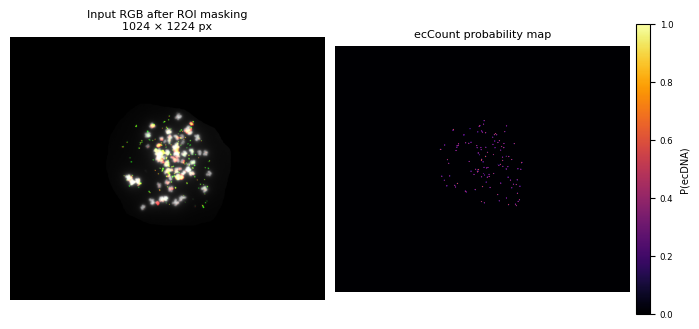

  Saved: fig5_probability_map.svg


In [7]:
# ── Fig 5A: ecCount probability map, if live inference was run ──────────────

if live_prob is not None:
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))

    axes[0].imshow(rgb_resized)
    axes[0].set_title('Input RGB after ROI masking\n1024 × 1224 px')
    axes[0].axis('off')

    im = axes[1].imshow(live_prob, cmap='inferno', vmin=0, vmax=1)
    axes[1].set_title('ecCount probability map')
    axes[1].axis('off')

    fig.colorbar(
        im,
        ax=axes[1],
        fraction=0.046,
        pad=0.02,
        label='P(ecDNA)',
    )

    fig.tight_layout()
    display(fig)
    save_fig(fig, 'fig5_probability_map')
    plt.close(fig)

else:
    print('fig5_probability_map was not generated because live inference was skipped.')

### Postprocessing pipeline

The next cell renders the five-step postprocessing pipeline applied to the probability map: smoothing → ROI re-mask → local-maximum detection → threshold at 0.35 → greedy Euclidean NMS. The intermediate panel labels report the number of peaks at each stage. The cell also produces the threshold-mask vs peaks-mask comparison at full image resolution.

Saved as: `fig5_postproc_steps.svg` and `fig5_threshold_vs_peaks.svg`. Postprocessing counts are saved to `source_fig5_live_eccount_postprocessing.csv`.


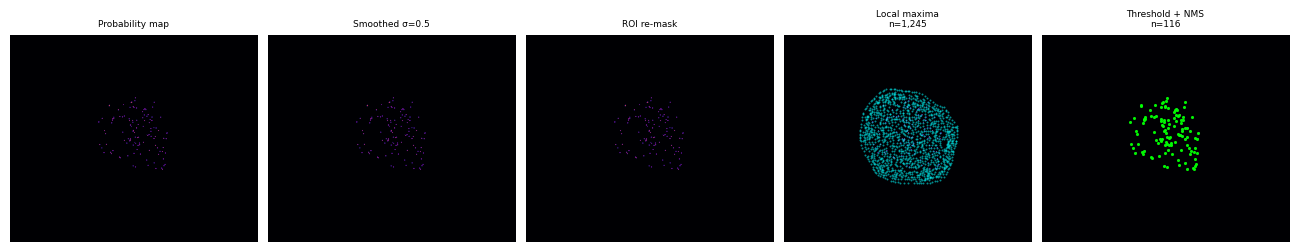

  Saved: fig5_postproc_steps.svg


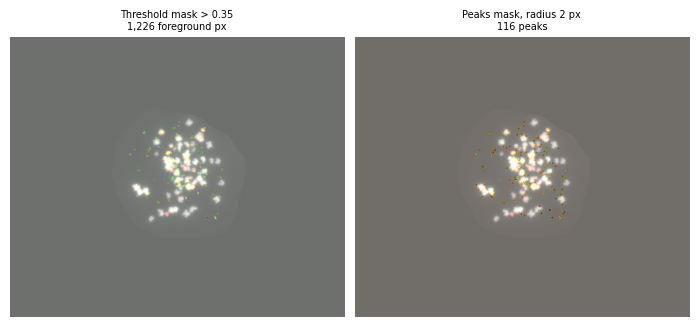

  Saved: fig5_threshold_vs_peaks.svg


In [8]:
# ── Fig 5B/C: ecCount postprocessing outputs, if live inference was run ─────

if live_prob is not None:
    # Five-step postprocessing strip.
    panels = [
        ('Probability map', live_prob, 'inferno'),
        ('Smoothed σ=0.5', smoothed, 'inferno'),
        ('ROI re-mask', roi_re_applied, 'inferno'),
        (f'Local maxima\nn={len(peaks_xy):,}', None, None),
        (f'Threshold + NMS\nn={len(peaks_final):,}', None, None),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(13.0, 2.8))

    for ax, (title, img, cmap) in zip(axes, panels):
        if img is not None:
            ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(roi_re_applied, cmap='inferno', vmin=0, vmax=1)
            if title.startswith('Local') and len(peaks_xy):
                ax.scatter(
                    peaks_xy[:, 1],
                    peaks_xy[:, 0],
                    s=2,
                    c='cyan',
                    alpha=0.55,
                    linewidths=0,
                )
            elif len(peaks_final):
                ax.scatter(
                    peaks_final[:, 1],
                    peaks_final[:, 0],
                    s=5,
                    c='lime',
                    alpha=0.95,
                    linewidths=0,
                )

        ax.set_title(title, fontsize=6.5)
        ax.axis('off')

    fig.tight_layout()
    display(fig)
    save_fig(fig, 'fig5_postproc_steps')
    plt.close(fig)

    # Threshold mask vs peaks mask.
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))

    axes[0].imshow(rgb_resized)
    axes[0].imshow(thr_mask_resized, cmap='Greens', alpha=0.45, vmin=0, vmax=1)
    axes[0].set_title(
        f'Threshold mask > 0.35\n{int(thr_mask_resized.sum()):,} foreground px',
        fontsize=7,
    )
    axes[0].axis('off')

    axes[1].imshow(rgb_resized)
    axes[1].imshow(peaks_mask_resized, cmap='Oranges', alpha=0.45, vmin=0, vmax=1)
    axes[1].set_title(
        f'Peaks mask, radius 2 px\n{len(peaks_final):,} peaks',
        fontsize=7,
    )
    axes[1].axis('off')

    fig.tight_layout()
    display(fig)
    save_fig(fig, 'fig5_threshold_vs_peaks')
    plt.close(fig)

    postproc_source = pd.DataFrame([{
        'local_maxima': len(peaks_xy),
        'after_threshold_0_35': len(peaks_thr),
        'after_nms': len(peaks_final),
        'threshold_mask_foreground_px': int(thr_mask_resized.sum()),
    }])
    postproc_source.to_csv(
        OUT_DIR / 'source_fig5_live_eccount_postprocessing.csv',
        index=False,
    )

else:
    print('fig5_postproc_steps and fig5_threshold_vs_peaks were not generated because live inference was skipped.')

### Threshold mask vs peaks mask on the anchor crop

The full-resolution comparison above is informative but visually washed out because most pixels lie outside the ROI. The next cell renders the same comparison on the anchor crop with a 1–99.5 percentile contrast stretch and crisp peak markers, which is a much clearer view of how the two ecCount output modes differ on the same image.

Saved as: `fig5_threshold_vs_peaks_zoomed.svg`.


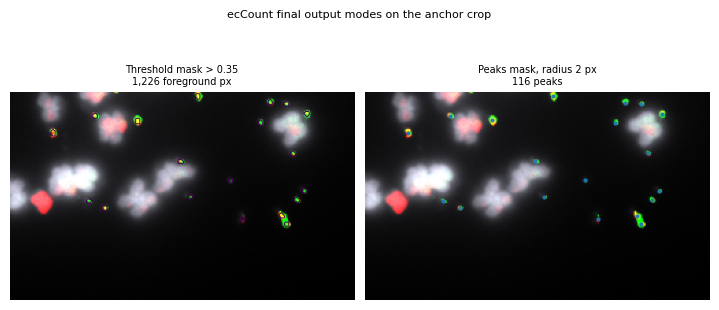

  Saved: fig5_threshold_vs_peaks_zoomed.svg
Resized crop shown: x=550:802, y=568:720
Peaks in displayed crop: 19 / 116


In [9]:
if thr_mask_resized is None:
    print('fig5_threshold_vs_peaks_zoomed was not generated because live inference was skipped.')
else:
    # ── Fig 5C: Threshold mask vs peaks mask on anchor crop ─────────────────────

    def scale_bbox_to_resized(bbox, full_shape, resized_shape):
        """Map full-resolution bbox coordinates to resized image coordinates."""
        x0, y0, x1, y1 = bbox
        full_h, full_w = full_shape[:2]
        resized_h, resized_w = resized_shape[:2]

        sx = resized_w / full_w
        sy = resized_h / full_h

        return [
            int(round(x0 * sx)),
            int(round(y0 * sy)),
            int(round(x1 * sx)),
            int(round(y1 * sy)),
        ]


    def expand_bbox(bbox, image_shape, scale=2.2):
        """Expand bbox around its centre and clip to image bounds."""
        x0, y0, x1, y1 = bbox
        h, w = image_shape[:2]

        cx = (x0 + x1) // 2
        cy = (y0 + y1) // 2
        half_w = int((x1 - x0) * scale / 2)
        half_h = int((y1 - y0) * scale / 2)

        ex0 = max(0, cx - half_w)
        ex1 = min(w, cx + half_w)
        ey0 = max(0, cy - half_h)
        ey1 = min(h, cy + half_h)

        return ex0, ey0, ex1, ey1


    def robust_rgb_display(rgb):
        """Contrast-stretch RGB for visualization only."""
        arr = rgb.astype(np.float32)
        out = np.zeros_like(arr, dtype=np.float32)

        for c in range(3):
            lo, hi = np.percentile(arr[..., c], [1, 99.5])
            if hi > lo:
                out[..., c] = np.clip((arr[..., c] - lo) / (hi - lo), 0, 1)
            else:
                out[..., c] = arr[..., c] / 255.0

        return np.clip(out, 0, 1)


    # Convert the original locked anchor inset to resized model coordinates.
    bbox_resized = scale_bbox_to_resized(
        ANCHOR_INSET_BBOX,
        full_shape=anchor_rgb.shape,
        resized_shape=rgb_resized.shape,
    )
    rx0, ry0, rx1, ry1 = expand_bbox(
        bbox_resized,
        image_shape=rgb_resized.shape,
        scale=2.4,
    )

    rgb_crop = robust_rgb_display(rgb_resized[ry0:ry1, rx0:rx1])
    thr_crop = thr_mask_resized[ry0:ry1, rx0:rx1]
    peaks_crop = peaks_mask_resized[ry0:ry1, rx0:rx1]

    # Convert final peak coordinates to crop-local coordinates.
    peaks_in_crop = []
    for py, px in peaks_final:
        if ry0 <= py < ry1 and rx0 <= px < rx1:
            peaks_in_crop.append((py - ry0, px - rx0))
    peaks_in_crop = np.array(peaks_in_crop, dtype=int) if peaks_in_crop else np.empty((0, 2), dtype=int)

    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4))

    # Threshold-mask panel: RGB + sharp contour rather than washed-out full alpha fill.
    axes[0].imshow(rgb_crop)
    thr_contours, _ = cv2.findContours(
        thr_crop.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    axes[0].contour(thr_crop, levels=[0.5], linewidths=0.7)
    axes[0].set_title(
        f'Threshold mask > 0.35\n{int(thr_mask_resized.sum()):,} foreground px',
        fontsize=7,
    )
    axes[0].axis('off')

    # Peaks panel: RGB + peak centres as crisp points.
    axes[1].imshow(rgb_crop)
    if len(peaks_in_crop):
        axes[1].scatter(
            peaks_in_crop[:, 1],
            peaks_in_crop[:, 0],
            s=9,
            linewidths=0,
            alpha=0.95,
        )
    axes[1].set_title(
        f'Peaks mask, radius 2 px\n{len(peaks_final):,} peaks',
        fontsize=7,
    )
    axes[1].axis('off')

    fig.suptitle('ecCount final output modes on the anchor crop', fontsize=8, y=1.02)
    fig.tight_layout()

    display(fig)
    save_fig(fig, 'fig5_threshold_vs_peaks_zoomed')
    plt.close(fig)

    print(f'Resized crop shown: x={rx0}:{rx1}, y={ry0}:{ry1}')
    print(f'Peaks in displayed crop: {len(peaks_in_crop):,} / {len(peaks_final):,}')

## §4 — ecCount training curves

This section documents the training run that produced the released ecCount
checkpoint. The curve is included as a training-quality diagnostic, not as a
benchmark result. The checkpoint used in the paper is selected by the minimum
validation loss, while model comparison in later sections is computed from the
frozen benchmark CSVs.

The training history is read from `outputs/eccount_training/train_history.csv`.
The expected run used Adam with learning rate 1e-4, weighted BCE plus SoftDice
loss, and ReduceLROnPlateau scheduling. The vertical marker identifies the
epoch with the lowest validation loss.

Training history: 70 epochs | best epoch = 49 | best val_loss = 0.6421 | train_loss at best epoch = 0.6385
Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig5_training_curves.csv


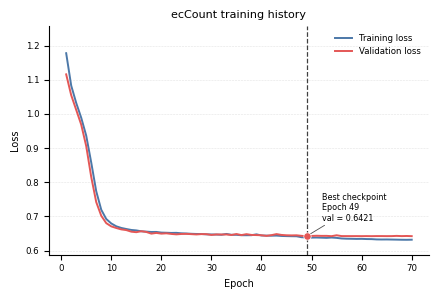

  Saved: fig5_training_curves.svg


In [10]:
# ── Fig 5D: ecCount training and validation loss curves ─────────────────────
# Source: outputs/eccount_training/train_history.csv
# Output: fig5_training_curves.{svg,png} + source_fig5_training_curves.csv

if not TRAIN_HIST.exists():
    print(f'Training history not found: {TRAIN_HIST}')

else:
    train_hist = pd.read_csv(TRAIN_HIST)

    # Be defensive about column names across training-script revisions.
    column_aliases = {
        'epoch':       ['epoch', 'epoch_completed'],
        'train_loss':  ['train_loss', 'loss_train', 'mean_train_loss'],
        'val_loss':    ['val_loss', 'loss_val', 'mean_val_loss'],
        'lr':          ['lr', 'learning_rate'],
    }

    def find_column(df, candidates, required=True):
        for c in candidates:
            if c in df.columns:
                return c
        if required:
            raise KeyError(
                f'None of the expected columns were found: {candidates}. '
                f'Available columns: {list(df.columns)}'
            )
        return None

    epoch_col = find_column(train_hist, column_aliases['epoch'])
    train_col = find_column(train_hist, column_aliases['train_loss'])
    val_col = find_column(train_hist, column_aliases['val_loss'])
    lr_col = find_column(train_hist, column_aliases['lr'], required=False)

    plot_df = train_hist[[epoch_col, train_col, val_col]].copy()
    plot_df = plot_df.rename(columns={
        epoch_col: 'epoch',
        train_col: 'train_loss',
        val_col: 'val_loss',
    })

    if lr_col is not None:
        plot_df['learning_rate'] = train_hist[lr_col].values

    plot_df = plot_df.sort_values('epoch').reset_index(drop=True)

    best_idx = int(plot_df['val_loss'].idxmin())
    best_epoch = int(plot_df.loc[best_idx, 'epoch'])
    best_val = float(plot_df.loc[best_idx, 'val_loss'])
    best_train = float(plot_df.loc[best_idx, 'train_loss'])

    print(
        f'Training history: {len(plot_df):,} epochs | '
        f'best epoch = {best_epoch} | '
        f'best val_loss = {best_val:.4f} | '
        f'train_loss at best epoch = {best_train:.4f}'
    )

    source_csv = OUT_DIR / 'source_fig5_training_curves.csv'
    plot_df.to_csv(source_csv, index=False)
    print(f'Saved source data: {source_csv}')

    fig, ax = plt.subplots(figsize=(4.4, 3.0))

    ax.plot(
        plot_df['epoch'],
        plot_df['train_loss'],
        label='Training loss',
        color='#4C78A8',
        linewidth=1.4,
    )
    ax.plot(
        plot_df['epoch'],
        plot_df['val_loss'],
        label='Validation loss',
        color='#E45756',
        linewidth=1.4,
    )

    ax.axvline(
        best_epoch,
        color='0.25',
        linestyle='--',
        linewidth=0.9,
        zorder=1,
    )
    ax.scatter(
        [best_epoch],
        [best_val],
        color='#E45756',
        edgecolor='white',
        linewidth=0.5,
        s=28,
        zorder=5,
    )

    ax.annotate(
        f'Best checkpoint\nEpoch {best_epoch}\nval = {best_val:.4f}',
        xy=(best_epoch, best_val),
        xytext=(best_epoch + 3, best_val + 0.04),
        fontsize=5.8,
        ha='left',
        va='bottom',
        arrowprops=dict(
            arrowstyle='-',
            color='0.3',
            linewidth=0.6,
            shrinkA=0,
            shrinkB=3,
        ),
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('ecCount training history')
    ax.legend(loc='upper right', frameon=False, fontsize=6.2)

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.4,
        alpha=0.35,
    )
    ax.set_axisbelow(True)

    # Keep the y-axis tight but leave room for the annotation.
    ymin = min(plot_df['train_loss'].min(), plot_df['val_loss'].min())
    ymax = max(plot_df['train_loss'].max(), plot_df['val_loss'].max())
    pad = 0.08 * (ymax - ymin) if ymax > ymin else 0.1
    ax.set_ylim(max(0, ymin - pad), ymax + 1.8 * pad)

    fig.tight_layout()
    display(fig)
    save_fig(fig, 'fig5_training_curves')
    plt.close(fig)

## §5 — Headline benchmark numbers

We now move from the illustrative anchor image to the frozen six-model
benchmark. All numbers in this section are read directly from
`release/frozen_results/or_matching/`; no inference or matching is recomputed
inside the notebook.

`summary_overall.csv` provides the aggregate metrics used for the headline
comparison, and `per_image_metrics.csv` is retained for downstream plots that
require per-image counts, splits, cell lines, or count bins. The primary
headline metric is object-level F1 under the canonical OR matching policy.

In [11]:
# ── §5: Load frozen OR-matching benchmark results ───────────────────────────
# These CSVs are the source of truth for the six-model comparison.

SUMMARY_OVERALL_CSV = FROZEN_OR / 'summary_overall.csv'
PER_IMAGE_CSV = FROZEN_OR / 'per_image_metrics.csv'

for path in [SUMMARY_OVERALL_CSV, PER_IMAGE_CSV]:
    if not path.exists():
        raise FileNotFoundError(f'Frozen benchmark file not found: {path}')

summary_overall = pd.read_csv(SUMMARY_OVERALL_CSV)
per_image = pd.read_csv(PER_IMAGE_CSV)

required_summary_cols = {'model'}
required_per_image_cols = {'model', 'split', 'cell_line'}

missing_summary = required_summary_cols - set(summary_overall.columns)
missing_per_image = required_per_image_cols - set(per_image.columns)

if missing_summary:
    raise KeyError(
        f'summary_overall is missing required columns: {sorted(missing_summary)}. '
        f'Available columns: {list(summary_overall.columns)}'
    )

if missing_per_image:
    raise KeyError(
        f'per_image_metrics is missing required columns: {sorted(missing_per_image)}. '
        f'Available columns: {list(per_image.columns)}'
    )

# Standardise display labels where needed.
summary_overall = summary_overall.copy()
per_image = per_image.copy()

if 'cell_line' in per_image.columns:
    per_image['cell_line_display'] = per_image['cell_line'].apply(canonical_cell_line)

# Keep only the six paper models and enforce the figure order.
summary_overall_6 = summary_overall[summary_overall['model'].isin(MODEL_ORDER)].copy()
summary_overall_6['model'] = pd.Categorical(
    summary_overall_6['model'],
    categories=MODEL_ORDER,
    ordered=True,
)
summary_overall_6 = summary_overall_6.sort_values('model').reset_index(drop=True)

per_image_6 = per_image[per_image['model'].isin(MODEL_ORDER)].copy()
per_image_6['model'] = pd.Categorical(
    per_image_6['model'],
    categories=MODEL_ORDER,
    ordered=True,
)

print(f'summary_overall: {summary_overall.shape[0]:,} rows × {summary_overall.shape[1]:,} columns')
print(f'per_image_metrics: {per_image.shape[0]:,} rows × {per_image.shape[1]:,} columns')
print(f'Six-model summary rows retained: {len(summary_overall_6):,}')
print('Models in plotting order:')
for model_name in summary_overall_6['model'].astype(str).tolist():
    print(f'  - {model_name}')

display(summary_overall_6)

summary_overall: 6 rows × 27 columns
per_image_metrics: 6,870 rows × 32 columns
Six-model summary rows retained: 6
Models in plotting order:
  - Classic (after opt)
  - Label Engine
  - ecSeg
  - MIA
  - ecCount (threshold mask)
  - ecCount (peaks)


,model,n_images,obj_tp,obj_fp,obj_fn,obj_ignored,pred_count,gt_count,obj_precision,obj_recall,...,pix_f1,pix_iou,pix_dice,count_mae,count_trimmed_mae,count_mdape,count_rmse,count_bias,count_pearson_r,count_spearman_rho
0,Classic (after opt),1145,162540,27720,65499,9973,200233,228039,0.854305,0.712773,...,0.126072,0.067277,0.126072,44.924017,37.309091,19.379845,70.077549,-24.284716,0.913421,0.911792
1,Label Engine,1145,172365,17639,55674,5101,195105,228039,0.907165,0.755858,...,0.247474,0.141210,0.247474,36.027948,27.218692,13.223140,68.318417,-28.763319,0.918850,0.913777
2,ecSeg,1145,73746,16297,154293,2350,92393,228039,0.819009,0.323392,...,0.146012,0.078756,0.146012,121.486463,107.240812,72.500000,172.549478,-118.468122,0.604124,0.527729
3,MIA,1145,161874,14615,66165,5040,181529,228039,0.917190,0.709852,...,0.206260,0.114989,0.206260,46.951965,37.189504,18.421053,84.426304,-40.620087,0.881944,0.862968
4,ecCount (threshold mask),1145,200818,8923,27221,5198,214939,228039,0.957457,0.880630,...,0.310865,0.184038,0.310865,18.076856,14.592486,7.070707,30.176714,-11.441048,0.986963,0.983583
5,ecCount (peaks),1145,211160,9130,16879,8156,228446,228039,0.958555,0.925982,...,0.320538,0.190858,0.320538,13.111790,10.325688,5.263158,21.470870,0.355459,0.990757,0.985735


### Headline F1 panel

The next cell renders the six-model headline figure: pooled object-level F1 per model under the canonical OR matching policy, computed over all benchmark images. ecCount peaks (0.942) is the highest-scoring model, followed by ecCount threshold (0.917), Label Engine (0.825), MIA (0.800), Classic after opt (0.777), and ecSeg (0.464).

Saved as: `fig6_f1_overall.svg`. Source CSV: `source_fig6_f1_overall.csv`.


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_f1_overall.csv


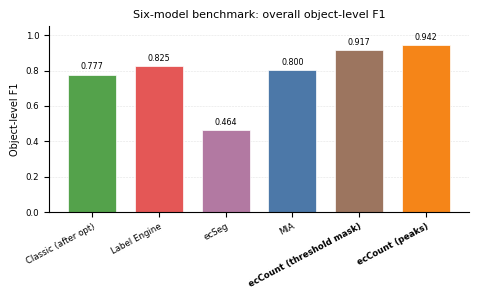

  Saved: fig6_f1_overall.svg


In [12]:
# ── Fig 6A: Headline object-level F1 per model ──────────────────────────────
# Source: release/frozen_results/or_matching/summary_overall.csv
# Output: fig6_f1_overall.{svg,png} + source_fig6_f1_overall.csv

metric_candidates = ['obj_f1', 'object_f1', 'f1']
f1_col = next((c for c in metric_candidates if c in summary_overall_6.columns), None)

if f1_col is None:
    raise KeyError(
        f'Could not find an object-F1 column. Tried {metric_candidates}. '
        f'Available columns: {list(summary_overall_6.columns)}'
    )

plot_df = summary_overall_6[['model', f1_col]].copy()
plot_df = plot_df.rename(columns={f1_col: 'object_f1'})
plot_df['object_f1'] = plot_df['object_f1'].astype(float)

source_csv = OUT_DIR / 'source_fig6_f1_overall.csv'
plot_df.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

fig, ax = plt.subplots(figsize=(4.8, 3.0))

x = np.arange(len(plot_df))
bar_colors = [MODEL_COLORS[str(m)] for m in plot_df['model']]

bars = ax.bar(
    x,
    plot_df['object_f1'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.72,
)

for bar, val in zip(bars, plot_df['object_f1']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(val + 0.018, 1.02),
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=5.8,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df['model'].astype(str),
    rotation=28,
    ha='right',
    rotation_mode='anchor',
)
ax.set_ylabel('Object-level F1')
ax.set_title('Six-model benchmark: overall object-level F1')
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

# Lightly emphasize the two ecCount output modes.
for tick_label in ax.get_xticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_f1_overall')
plt.close(fig)

## §6 — Object-level F1 by cell line

We next stratify the six-model benchmark by cell line. This view checks whether
the headline ranking is consistent across biological contexts rather than being
driven by a single dominant cell line.

The plot uses the frozen OR-matching results. When
`summary_by_cell_line.csv` is available, it is used directly. Otherwise, the
same quantity is reconstructed from `per_image_metrics.csv` by summing
object-level TP, FP, and FN within each model–cell-line group.

Loaded: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/frozen_results/or_matching/summary_by_cell_line.csv
Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_f1_by_cell_line.csv


cell_line,NCI-H2170,SNU16,COLO320DM,NCI-H716
model,,,,
Classic (after opt),0.750,0.858,0.825,0.901
Label Engine,0.878,0.569,0.692,0.710
ecSeg,0.529,0.112,0.224,0.316
MIA,0.852,0.497,0.766,0.724
ecCount (threshold mask),0.917,0.913,0.907,0.939
ecCount (peaks),0.944,0.932,0.915,0.952


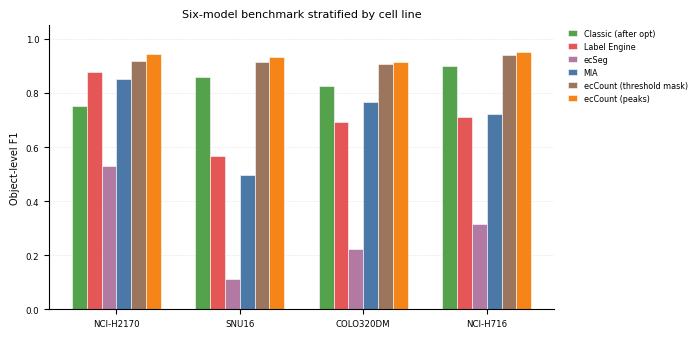

  Saved: fig6_f1_by_cell_line.svg


In [13]:
# ── Fig 6B: Object-level F1 by cell line ────────────────────────────────────
# Source: release/frozen_results/or_matching/summary_by_cell_line.csv
# Fallback: aggregate TP/FP/FN from per_image_metrics.csv
# Output: fig6_f1_by_cell_line.{svg,png} + source_fig6_f1_by_cell_line.csv

SUMMARY_BY_CELL_LINE_CSV = FROZEN_OR / 'summary_by_cell_line.csv'

def find_metric_column(df, candidates, label):
    """Return the first available metric column from a list of aliases."""
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )

if SUMMARY_BY_CELL_LINE_CSV.exists():
    summary_cl = pd.read_csv(SUMMARY_BY_CELL_LINE_CSV)
    print(f'Loaded: {SUMMARY_BY_CELL_LINE_CSV}')

    required_cols = {'model', 'cell_line'}
    missing = required_cols - set(summary_cl.columns)
    if missing:
        raise KeyError(
            f'{SUMMARY_BY_CELL_LINE_CSV.name} is missing required columns: '
            f'{sorted(missing)}. Available columns: {list(summary_cl.columns)}'
        )

    cl_f1_col = find_metric_column(
        summary_cl,
        candidates=['obj_f1', 'object_f1', 'f1'],
        label='object-level F1 column',
    )

    cl_long = summary_cl[['model', 'cell_line', cl_f1_col]].copy()
    cl_long = cl_long.rename(columns={cl_f1_col: 'object_f1'})
    cl_long['object_f1'] = cl_long['object_f1'].astype(float)

else:
    print(
        f'{SUMMARY_BY_CELL_LINE_CSV.name} not found; '
        'reconstructing cell-line F1 from per_image_metrics.csv'
    )

    required_cols = {'model', 'cell_line', 'obj_tp', 'obj_fp', 'obj_fn'}
    missing = required_cols - set(per_image_6.columns)
    if missing:
        raise KeyError(
            f'per_image_metrics is missing columns needed for fallback '
            f'aggregation: {sorted(missing)}. '
            f'Available columns: {list(per_image_6.columns)}'
        )

    cl_long = (
        per_image_6
        .copy()
        .assign(cell_line=lambda d: d['cell_line'].apply(canonical_cell_line))
        .groupby(['model', 'cell_line'], observed=False, as_index=False)
        .agg(
            tp=('obj_tp', 'sum'),
            fp=('obj_fp', 'sum'),
            fn=('obj_fn', 'sum'),
            n_images=('model', 'size'),
        )
    )

    denom = 2 * cl_long['tp'] + cl_long['fp'] + cl_long['fn']
    cl_long['object_f1'] = np.where(
        denom > 0,
        (2 * cl_long['tp']) / denom,
        np.nan,
    )

    cl_long = cl_long[['model', 'cell_line', 'object_f1', 'n_images']]

# Standardise labels and enforce plotting order.
cl_long['cell_line'] = cl_long['cell_line'].apply(canonical_cell_line)
cl_long = cl_long[
    cl_long['model'].isin(MODEL_ORDER)
    & cl_long['cell_line'].isin(CL_ORDER)
].copy()

cl_long['model'] = pd.Categorical(
    cl_long['model'],
    categories=MODEL_ORDER,
    ordered=True,
)
cl_long['cell_line'] = pd.Categorical(
    cl_long['cell_line'],
    categories=CL_ORDER,
    ordered=True,
)

cl_long = cl_long.sort_values(['cell_line', 'model']).reset_index(drop=True)

source_csv = OUT_DIR / 'source_fig6_f1_by_cell_line.csv'
cl_long.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

f1_by_cell_line = (
    cl_long
    .pivot(index='model', columns='cell_line', values='object_f1')
    .reindex(index=MODEL_ORDER, columns=CL_ORDER)
)

display(f1_by_cell_line.round(3))

fig, ax = plt.subplots(figsize=(8.6, 3.4))

n_cell_lines = len(CL_ORDER)
n_models = len(MODEL_ORDER)
x = np.arange(n_cell_lines)
bar_w = 0.12

for i, model_name in enumerate(MODEL_ORDER):
    vals = f1_by_cell_line.loc[model_name].astype(float).values
    offset = (i - (n_models - 1) / 2) * bar_w

    ax.bar(
        x + offset,
        vals,
        width=bar_w,
        color=MODEL_COLORS[model_name],
        edgecolor='white',
        linewidth=0.4,
        label=model_name,
    )

ax.set_xticks(x)
ax.set_xticklabels(CL_ORDER)
ax.set_ylabel('Object-level F1')
ax.set_title('Six-model benchmark stratified by cell line')
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

# Legend outside the plotting area
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=5.8,
    handlelength=1.2,
    ncol=1,
)

# Leave room on the right for the external legend
fig.tight_layout(rect=[0, 0, 0.82, 1])

display(fig)
save_fig(fig, 'fig6_f1_by_cell_line')
plt.close(fig)

## §7 — Object-level F1 by count bin

We next stratify performance by ecDNA density. This analysis tests whether the relative behaviour of the six models changes across sparse and crowded images, from very low ecDNA burden (0–9 objects) to very high burden (300+ objects).

**Two patterns are visible in the figure below.**

1. *All non-ecCount models collapse in the sparsest 0–9 bin* (F1 ≤ 0.20). At very low GS counts, the pooled F1 denominator is small and a handful of mis-detections destroy the score. This is a known artefact of object-level F1 at low N rather than a model pathology.
2. *ecCount is essentially density-invariant from 10 onwards.* ecCount peaks holds F1 ≈ 0.93–0.95 across the four populated count bins (≤ 3 pp range). The other models gain 4–18 pp moving from sparse to dense — i.e. they are noticeably less robust to varying ecDNA burden.

The preferred source is `summary_by_density_bin.csv` from the frozen OR-matching benchmark. If that file is unavailable, the same quantity is reconstructed from `per_image_metrics.csv` by summing object-level TP, FP, and FN within each model–density-bin group.


Loaded: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/frozen_results/or_matching/summary_by_density_bin.csv
Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_f1_by_density.csv


density_bin,0-9,10-49,50-149,150-299,300+
model,,,,,
Classic (after opt),0.143,0.740,0.735,0.788,0.791
Label Engine,0.122,0.662,0.797,0.819,0.848
ecSeg,0.028,0.233,0.388,0.457,0.512
MIA,0.194,0.673,0.777,0.793,0.823
ecCount (threshold mask),0.191,0.926,0.913,0.921,0.917
ecCount (peaks),0.190,0.932,0.928,0.941,0.951


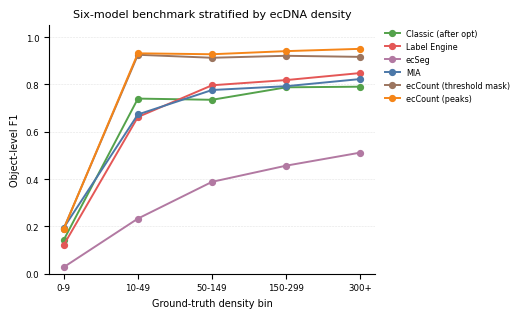

  Saved: fig6_f1_by_density.svg


In [14]:
# ── Fig 6C: Object-level F1 by count bin ──────────────────────────────────
# Source: release/frozen_results/or_matching/summary_by_density_bin.csv
# Fallback: aggregate TP/FP/FN from per_image_metrics.csv
# Output: fig6_f1_by_density.{svg,png} + source_fig6_f1_by_density.csv

SUMMARY_BY_DENSITY_CSV = FROZEN_OR / 'summary_by_density_bin.csv'

def find_metric_column(df, candidates, label):
    """Return the first available metric column from a list of aliases."""
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )

if SUMMARY_BY_DENSITY_CSV.exists():
    summary_db = pd.read_csv(SUMMARY_BY_DENSITY_CSV)
    print(f'Loaded: {SUMMARY_BY_DENSITY_CSV}')

    required_cols = {'model', 'density_bin'}
    missing = required_cols - set(summary_db.columns)
    if missing:
        raise KeyError(
            f'{SUMMARY_BY_DENSITY_CSV.name} is missing required columns: '
            f'{sorted(missing)}. Available columns: {list(summary_db.columns)}'
        )

    db_f1_col = find_metric_column(
        summary_db,
        candidates=['obj_f1', 'object_f1', 'f1'],
        label='object-level F1 column',
    )

    db_long = summary_db[['model', 'density_bin', db_f1_col]].copy()
    db_long = db_long.rename(columns={db_f1_col: 'object_f1'})
    db_long['object_f1'] = db_long['object_f1'].astype(float)

else:
    print(
        f'{SUMMARY_BY_DENSITY_CSV.name} not found; '
        'reconstructing density-bin F1 from per_image_metrics.csv'
    )

    required_cols = {'model', 'density_bin', 'obj_tp', 'obj_fp', 'obj_fn'}
    missing = required_cols - set(per_image_6.columns)
    if missing:
        raise KeyError(
            f'per_image_metrics is missing columns needed for fallback '
            f'aggregation: {sorted(missing)}. '
            f'Available columns: {list(per_image_6.columns)}'
        )

    db_long = (
        per_image_6
        .copy()
        .groupby(['model', 'density_bin'], observed=False, as_index=False)
        .agg(
            tp=('obj_tp', 'sum'),
            fp=('obj_fp', 'sum'),
            fn=('obj_fn', 'sum'),
            n_images=('model', 'size'),
        )
    )

    denom = 2 * db_long['tp'] + db_long['fp'] + db_long['fn']
    db_long['object_f1'] = np.where(
        denom > 0,
        (2 * db_long['tp']) / denom,
        np.nan,
    )

    db_long = db_long[['model', 'density_bin', 'object_f1', 'n_images']]

# Enforce plotting order.
db_long = db_long[
    db_long['model'].isin(MODEL_ORDER)
    & db_long['density_bin'].isin(DENSITY_ORDER)
].copy()

db_long['model'] = pd.Categorical(
    db_long['model'],
    categories=MODEL_ORDER,
    ordered=True,
)
db_long['density_bin'] = pd.Categorical(
    db_long['density_bin'],
    categories=DENSITY_ORDER,
    ordered=True,
)

db_long = db_long.sort_values(['density_bin', 'model']).reset_index(drop=True)

source_csv = OUT_DIR / 'source_fig6_f1_by_density.csv'
db_long.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

f1_by_density = (
    db_long
    .pivot(index='model', columns='density_bin', values='object_f1')
    .reindex(index=MODEL_ORDER, columns=DENSITY_ORDER)
)

display(f1_by_density.round(3))

fig, ax = plt.subplots(figsize=(6.6, 3.2))

x = np.arange(len(DENSITY_ORDER))

for model_name in MODEL_ORDER:
    vals = f1_by_density.loc[model_name].astype(float).values
    ax.plot(
        x,
        vals,
        marker='o',
        markersize=4.2,
        linewidth=1.4,
        color=MODEL_COLORS[model_name],
        label=model_name,
    )

ax.set_xticks(x)
ax.set_xticklabels(DENSITY_ORDER)
ax.set_xlabel('Gold-standard count bin')
ax.set_ylabel('Object-level F1')
ax.set_title('Six-model benchmark stratified by ecDNA density')
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

# Legend outside the plotting area
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=5.8,
    handlelength=1.8,
    ncol=1,
)

# Leave room on the right for the external legend
fig.tight_layout(rect=[0, 0, 0.80, 1])

display(fig)
save_fig(fig, 'fig6_f1_by_density')
plt.close(fig)

## §8 — Count agreement between predicted and gold-standard ecDNA burden

Object-level F1 measures localisation quality, but ecDNA quantification also requires accurate per-image counts. Here we compare each model's predicted object count with the gold-standard connected-component count across all benchmark images.

Each panel shows one model on log-log axes with the identity line drawn dashed for reference. Points near the diagonal indicate good count calibration; points below the line indicate under-counting; points above the line indicate over-counting. The title reports the mean absolute error (MAE) and the signed bias.

**The bias column is the most informative single result in the notebook:**

| Model                     | Count bias (mean signed error) |
|---------------------------|--------------------------------|
| Classic (after opt)       | −24.3 |
| Label Engine              | −28.8 |
| ecSeg                     | −118.5 |
| MIA                       | −40.6 |
| ecCount (threshold mask)  | −11.4 |
| ecCount (peaks)           | **+0.4** |

Every model except ecCount peaks systematically *under-counts*. ecCount peaks is the only model that is bias-balanced on this benchmark. This is consistent with its training objective: ecCount predicts a Gaussian centred on each annotated point, so the peak-counting head recovers the annotated count distribution rather than a smaller-area mask.


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_count_agreement.csv


,model,n_images,count_mae,count_bias,median_abs_error,gt_count_median,pred_count_median
0,Classic (after opt),1145,44.924,-24.285,27.0,159.0,140.0
1,Label Engine,1145,36.028,-28.763,18.0,159.0,129.0
2,ecSeg,1145,121.486,-118.468,86.0,159.0,43.0
3,MIA,1145,46.952,-40.620,24.0,159.0,116.0
4,ecCount (threshold mask),1145,18.077,-11.441,10.0,159.0,151.0
5,ecCount (peaks),1145,13.112,0.355,8.0,159.0,157.0


Saved summary data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_count_agreement_summary.csv


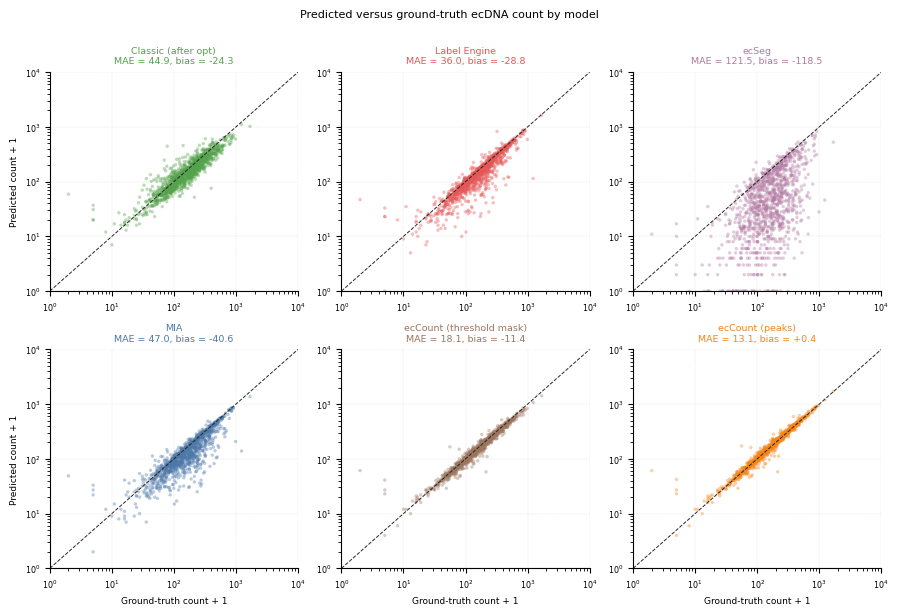

  Saved: fig6_count_agreement.svg


In [15]:
# ── Fig 6D: Predicted vs GS count agreement ─────────────────────────────────
# Source: release/frozen_results/or_matching/per_image_metrics.csv
# Output: fig6_count_agreement.{svg,png} + source_fig6_count_agreement.csv
#
# Notes:
#   - Scatter uses log-log axes, so zero counts are displayed with a +1 offset.
#   - MAE is computed on the original unshifted count scale.
#   - Frozen benchmark CSVs remain the source of truth; no matching is rerun.

count_col_candidates = {
    'gt_count': [
        'gt_count',
        'ecDNA_gt',
        'gt_objects',
        'obj_gt',
        'n_gt',
    ],
    'pred_count': [
        'pred_count',
        'predicted_count',
        'pred_objects',
        'obj_pred',
        'n_pred',
    ],
}

def find_count_column(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )

gt_count_col = find_count_column(
    per_image_6,
    count_col_candidates['gt_count'],
    'gold-standard count column',
)
pred_count_col = find_count_column(
    per_image_6,
    count_col_candidates['pred_count'],
    'predicted count column',
)

count_long = per_image_6[
    ['model', 'split', 'cell_line_display', 'density_bin', gt_count_col, pred_count_col]
].copy()

count_long = count_long.rename(columns={
    gt_count_col: 'gt_count',
    pred_count_col: 'pred_count',
})

count_long['gt_count'] = pd.to_numeric(count_long['gt_count'], errors='coerce')
count_long['pred_count'] = pd.to_numeric(count_long['pred_count'], errors='coerce')

count_long = count_long.dropna(subset=['gt_count', 'pred_count']).copy()
count_long = count_long[count_long['model'].isin(MODEL_ORDER)].copy()

count_long['model'] = pd.Categorical(
    count_long['model'],
    categories=MODEL_ORDER,
    ordered=True,
)

# Original-scale count error.
count_long['abs_error'] = (count_long['pred_count'] - count_long['gt_count']).abs()
count_long['signed_error'] = count_long['pred_count'] - count_long['gt_count']

# +1 shifted values for log-scale display so images with zero GT/predicted
# objects remain visible.
count_long['gt_count_plot'] = count_long['gt_count'] + 1
count_long['pred_count_plot'] = count_long['pred_count'] + 1

count_long = count_long.sort_values(['model', 'gt_count']).reset_index(drop=True)

source_csv = OUT_DIR / 'source_fig6_count_agreement.csv'
count_long.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

count_summary = (
    count_long
    .groupby('model', observed=False)
    .agg(
        n_images=('model', 'size'),
        count_mae=('abs_error', 'mean'),
        count_bias=('signed_error', 'mean'),
        median_abs_error=('abs_error', 'median'),
        gt_count_median=('gt_count', 'median'),
        pred_count_median=('pred_count', 'median'),
    )
    .reindex(MODEL_ORDER)
    .reset_index()
)

display(count_summary.round(3))

summary_csv = OUT_DIR / 'source_fig6_count_agreement_summary.csv'
count_summary.to_csv(summary_csv, index=False)
print(f'Saved summary data: {summary_csv}')

# Shared axis limits across panels.
max_count = max(
    count_long['gt_count_plot'].max(),
    count_long['pred_count_plot'].max(),
)
axis_hi = 10 ** np.ceil(np.log10(max_count))
axis_lo = 1

fig, axes = plt.subplots(2, 3, figsize=(9.0, 6.0))
axes = axes.flatten()

for ax, model_name in zip(axes, MODEL_ORDER):
    sub = count_long[count_long['model'] == model_name].copy()

    if sub.empty:
        ax.text(
            0.5,
            0.5,
            'No data',
            ha='center',
            va='center',
            transform=ax.transAxes,
            fontsize=8,
        )
        ax.set_title(model_name, fontsize=6.8)
        ax.axis('off')
        continue

    mae = float(sub['abs_error'].mean())
    bias = float(sub['signed_error'].mean())

    ax.scatter(
        sub['gt_count_plot'],
        sub['pred_count_plot'],
        s=6,
        alpha=0.38,
        color=MODEL_COLORS[model_name],
        edgecolor='none',
        rasterized=True,
    )

    ax.plot(
        [axis_lo, axis_hi],
        [axis_lo, axis_hi],
        color='0.15',
        linewidth=0.7,
        linestyle='--',
        zorder=1,
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(axis_lo, axis_hi)
    ax.set_ylim(axis_lo, axis_hi)

    ax.set_title(
        f'{model_name}\nMAE = {mae:.1f}, bias = {bias:+.1f}',
        fontsize=6.8,
        color=MODEL_COLORS[model_name],
    )

    ax.grid(
        which='major',
        linestyle='--',
        linewidth=0.35,
        alpha=0.35,
    )
    ax.set_axisbelow(True)

    ax.tick_params(axis='both', which='major', labelsize=5.8)

# Shared labels for the grid.
for ax in axes[3:]:
    ax.set_xlabel('Gold-standard count + 1', fontsize=6.5)

for ax in axes[::3]:
    ax.set_ylabel('Predicted count + 1', fontsize=6.5)

fig.suptitle(
    'Predicted versus gold-standard ecDNA count by model',
    fontsize=8,
    y=1.01,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_count_agreement')
plt.close(fig)

## §9 — Test-split-only headline F1

The primary held-out benchmark uses the test split only. Here we recompute
object-level F1 directly from `per_image_metrics.csv` by summing TP, FP, and
FN across the 175 held-out images for each model.

This cell is a reproducibility check: the direct aggregation should match the
test-split headline values reported in the paper table and figure panels. The
stratified analyses above use all benchmark images, whereas this panel isolates
the held-out test set.

### Held-out test split: pooled F1

The next cell pools `(TP, FP, FN)` across the 175 held-out test images for each model and computes pooled F1. These are the numbers that appear in the paper's primary table. Pooled F1 (rather than mean per-image F1) avoids over-weighting sparse images relative to dense ones.

Saved as: `fig6_test_only.svg`. Source CSV: `source_fig6_test_only_f1.csv`.


Test-split images per model:


,model,n_images
0,Classic (after opt),175
1,Label Engine,175
2,ecSeg,175
3,MIA,175
4,ecCount (threshold mask),175
5,ecCount (peaks),175


,model,n_images,tp,fp,fn,object_f1_test
0,Classic (after opt),175,24312,4819,9316,0.7748
1,Label Engine,175,25498,2689,8130,0.8250
2,ecSeg,175,12234,2281,21394,0.5082
3,MIA,175,24482,2136,9146,0.8127
4,ecCount (threshold mask),175,29674,1512,3954,0.9157
5,ecCount (peaks),175,31137,1545,2491,0.9391


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_test_only_f1.csv


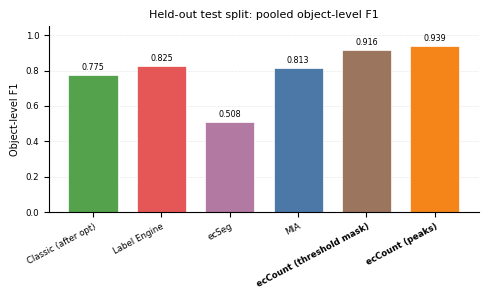

  Saved: fig6_test_only.svg


In [16]:
# ── Fig 6E: Test-split-only object-level F1 ─────────────────────────────────
# Source: release/frozen_results/or_matching/per_image_metrics.csv
# Output: fig6_test_only.{svg,png} + source_fig6_test_only_f1.csv
#
# Direct aggregation:
#   F1 = 2TP / (2TP + FP + FN)
#
# This avoids averaging per-image F1 values, which would weight sparse and dense
# images equally. Instead, each model is scored from the pooled object-level
# contingency counts across the held-out test split.

required_cols = {'model', 'split', 'obj_tp', 'obj_fp', 'obj_fn'}
missing = required_cols - set(per_image_6.columns)

if missing:
    raise KeyError(
        f'per_image_metrics is missing columns required for test-split F1: '
        f'{sorted(missing)}. Available columns: {list(per_image_6.columns)}'
    )

test_pim = per_image_6[per_image_6['split'].astype(str).str.lower() == 'test'].copy()

if test_pim.empty:
    raise ValueError('No rows with split == "test" were found in per_image_metrics.')

test_counts = (
    test_pim
    .groupby('model', observed=False)
    .agg(
        n_images=('model', 'size'),
        tp=('obj_tp', 'sum'),
        fp=('obj_fp', 'sum'),
        fn=('obj_fn', 'sum'),
    )
    .reindex(MODEL_ORDER)
    .reset_index()
)

for col in ['n_images', 'tp', 'fp', 'fn']:
    test_counts[col] = test_counts[col].fillna(0).astype(int)

denom = 2 * test_counts['tp'] + test_counts['fp'] + test_counts['fn']
test_counts['object_f1_test'] = np.where(
    denom > 0,
    (2 * test_counts['tp']) / denom,
    np.nan,
)

test_counts['model'] = pd.Categorical(
    test_counts['model'],
    categories=MODEL_ORDER,
    ordered=True,
)
test_counts = test_counts.sort_values('model').reset_index(drop=True)

print('Test-split images per model:')
display(test_counts[['model', 'n_images']])

display(test_counts.round({
    'object_f1_test': 4,
}))

source_csv = OUT_DIR / 'source_fig6_test_only_f1.csv'
test_counts.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

fig, ax = plt.subplots(figsize=(4.9, 3.0))

x = np.arange(len(test_counts))
bar_colors = [MODEL_COLORS[str(m)] for m in test_counts['model']]

bars = ax.bar(
    x,
    test_counts['object_f1_test'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.72,
)

for bar, val in zip(bars, test_counts['object_f1_test']):
    if np.isfinite(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(val + 0.018, 1.02),
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=5.8,
        )

ax.set_xticks(x)
ax.set_xticklabels(
    test_counts['model'].astype(str),
    rotation=28,
    ha='right',
    rotation_mode='anchor',
)

ax.set_ylabel('Object-level F1')
ax.set_title('Held-out test split: pooled object-level F1')
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

for tick_label in ax.get_xticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_test_only')
plt.close(fig)

## §10 — Test-split count MAE

Object-level F1 measures localization, but the downstream biological readout is
often the per-image ecDNA burden. We therefore also report test-split count
error for each model.

This panel uses the held-out test split only and computes mean absolute error
between the predicted object count and the gold-standard connected-component
count. Lower values indicate better count agreement.

### Held-out test split: count MAE

This is the count-error companion to the test-split F1 panel above. Lower is better. ecCount peaks (13.3) and ecCount threshold (17.6) are the two best counters; ecSeg (110.3) is by far the worst.

Saved as: `fig6_test_count_mae.svg`. Source CSV: `source_fig6_test_count_mae.csv`.


,model,n_images,count_mae,count_median_ae,count_bias,gt_count_mean,pred_count_mean
0,Classic (after opt),175,40.943,25.0,-17.354,192.16,174.806
1,Label Engine,175,34.366,18.0,-26.869,192.16,165.291
2,ecSeg,175,110.274,77.0,-107.417,192.16,84.743
3,MIA,175,40.394,21.0,-35.743,192.16,156.417
4,ecCount (threshold mask),175,17.617,11.0,-9.103,192.16,183.057
5,ecCount (peaks),175,13.309,8.0,1.880,192.16,194.040


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_test_count_mae.csv


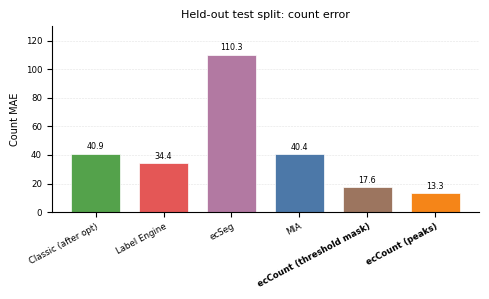

  Saved: fig6_test_count_mae.svg


In [17]:
# ── Fig 6F: Test-split count MAE per model ──────────────────────────────────
# Source: release/frozen_results/or_matching/per_image_metrics.csv
# Output: fig6_test_count_mae.{svg,png} + source_fig6_test_count_mae.csv
#
# This is the count-error companion to the held-out test F1 panel.

count_col_candidates = {
    'gt_count': [
        'gt_count',
        'ecDNA_gt',
        'gt_objects',
        'obj_gt',
        'n_gt',
    ],
    'pred_count': [
        'pred_count',
        'predicted_count',
        'pred_objects',
        'obj_pred',
        'n_pred',
    ],
}

def find_count_column(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )

gt_count_col = find_count_column(
    per_image_6,
    count_col_candidates['gt_count'],
    'gold-standard count column',
)
pred_count_col = find_count_column(
    per_image_6,
    count_col_candidates['pred_count'],
    'predicted count column',
)

test_counts = per_image_6[
    per_image_6['split'].astype(str).str.lower() == 'test'
].copy()

if test_counts.empty:
    raise ValueError('No rows with split == "test" were found in per_image_metrics.')

test_counts['gt_count'] = pd.to_numeric(test_counts[gt_count_col], errors='coerce')
test_counts['pred_count'] = pd.to_numeric(test_counts[pred_count_col], errors='coerce')
test_counts = test_counts.dropna(subset=['gt_count', 'pred_count']).copy()

test_counts['abs_count_error'] = (
    test_counts['pred_count'] - test_counts['gt_count']
).abs()
test_counts['signed_count_error'] = (
    test_counts['pred_count'] - test_counts['gt_count']
)

mae_df = (
    test_counts
    .groupby('model', observed=False)
    .agg(
        n_images=('model', 'size'),
        count_mae=('abs_count_error', 'mean'),
        count_median_ae=('abs_count_error', 'median'),
        count_bias=('signed_count_error', 'mean'),
        gt_count_mean=('gt_count', 'mean'),
        pred_count_mean=('pred_count', 'mean'),
    )
    .reindex(MODEL_ORDER)
    .reset_index()
)

mae_df['model'] = pd.Categorical(
    mae_df['model'],
    categories=MODEL_ORDER,
    ordered=True,
)
mae_df = mae_df.sort_values('model').reset_index(drop=True)

display(mae_df.round(3))

source_csv = OUT_DIR / 'source_fig6_test_count_mae.csv'
mae_df.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

fig, ax = plt.subplots(figsize=(4.9, 3.0))

x = np.arange(len(mae_df))
bar_colors = [MODEL_COLORS[str(m)] for m in mae_df['model']]

bars = ax.bar(
    x,
    mae_df['count_mae'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.72,
)

for bar, val in zip(bars, mae_df['count_mae']):
    if np.isfinite(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(mae_df['count_mae'].max() * 0.015, 0.5),
            f'{val:.1f}',
            ha='center',
            va='bottom',
            fontsize=5.8,
        )

ax.set_xticks(x)
ax.set_xticklabels(
    mae_df['model'].astype(str),
    rotation=28,
    ha='right',
    rotation_mode='anchor',
)

ax.set_ylabel('Count MAE')
ax.set_title('Held-out test split: count error')
ax.set_ylim(0, mae_df['count_mae'].max() * 1.18)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

for tick_label in ax.get_xticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

fig.tight_layout()
display(fig)
save_fig(fig, 'fig6_test_count_mae')
plt.close(fig)

## §11 — Output manifest

Finally, we print a manifest of the files generated by this notebook. This
provides a compact audit trail for collaborators: figures are
saved as SVG/PNG, and each quantitative panel has an accompanying source-data
CSV where applicable.

In [18]:
# ── §11: Notebook output manifest ───────────────────────────────────────────
# Print all generated figures and source-data files from this notebook.

generated_files = sorted(
    [
        p for p in OUT_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in {'.svg', '.png', '.csv'}
    ],
    key=lambda p: (p.suffix.lower(), p.name),
)

if not generated_files:
    print(f'No files found in {OUT_DIR}')
else:
    manifest_rows = []

    for p in generated_files:
        manifest_rows.append({
            'file': p.name,
            'type': p.suffix.lower().lstrip('.'),
            'size_kb': round(p.stat().st_size / 1024, 1),
            'path': str(p),
        })

    output_manifest = pd.DataFrame(manifest_rows)
    display(output_manifest)

    manifest_csv = OUT_DIR / 'notebook03_output_manifest.csv'
    output_manifest.to_csv(manifest_csv, index=False)

    print(f'Output directory: {OUT_DIR}')
    print(f'Files written: {len(output_manifest):,}')
    print(f'Saved manifest: {manifest_csv}')

    print('\nFigures:')
    for p in generated_files:
        if p.suffix.lower() in {'.svg', '.png'}:
            print(f'  - {p.name}')

    print('\nSource-data CSVs:')
    for p in generated_files:
        if p.suffix.lower() == '.csv':
            print(f'  - {p.name}')

,file,type,size_kb,path
0,notebook03_output_manifest.csv,csv,4.6,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
1,source_anchor_mask_qc.csv,csv,0.2,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
2,source_fig5_live_eccount_postprocessing.csv,csv,0.1,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
3,source_fig5_training_curves.csv,csv,2.0,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
4,source_fig6_count_agreement.csv,csv,381.7,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
5,source_fig6_count_agreement_summary.csv,csv,0.5,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
6,source_fig6_f1_by_cell_line.csv,csv,1.0,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
7,source_fig6_f1_by_density.csv,csv,1.1,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
8,source_fig6_f1_overall.csv,csv,0.2,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
9,source_fig6_test_count_mae.csv,csv,0.6,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...


Output directory: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03
Files written: 35
Saved manifest: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/notebook03_output_manifest.csv

Figures:
  - fig4_qualitative_six_models.png
  - fig5_postproc_steps.png
  - fig5_probability_map.png
  - fig5_threshold_vs_peaks.png
  - fig5_threshold_vs_peaks_zoomed.png
  - fig5_training_curves.png
  - fig6_count_agreement.png
  - fig6_f1_by_cell_line.png
  - fig6_f1_by_density.png
  - fig6_f1_overall.png
  - fig6_test_count_mae.png
  - fig6_test_only.png
  - fig4_qualitative_six_models.svg
  - fig5_postproc_steps.svg
  - fig5_probability_map.svg
  - fig5_threshold_vs_peaks.svg
  - fig5_threshold_vs_peaks_zoomed.svg
  - fig5_training_curves.svg
  - fig6_count_agreement.svg
  - fig6_f1_by_cell_line.svg
  - fig6_f1_by_density.svg
  - fig6_f1_overall.svg
  - fig6_test_count_mae.svg
  - fig6_test_only.svg

Source-data CSVs:
  - notebook03_output_manifest.c